# Unsupervised Learning Script

In [2]:
#Import required packages
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
import gensim.downloader
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from scipy.sparse import hstack, csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples
from IPython.display import display, Markdown
import seaborn as sns
import os
import warnings
from sklearn.base import clone

warnings.filterwarnings("ignore")

#import file created from data preparation script
downloads_folder = os.path.join(os.path.expanduser('~'), 'Downloads')
file_path = os.path.join(downloads_folder, 'df_american_movies_post1969.csv')
df = pd.read_csv(file_path)

#create final_genre_list field for later feature exploration
df['final_genre_list'] = df['final_genre'].apply((lambda g: [x.strip() for x in g.split(',') if x.strip()]))
display(df.head())

C:\Users\freya\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\freya\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\freya\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


,Release Year,Title,Plot,PlotSummary,final_genre,final_director,final_cast,final_genre_list
0,1970,Adam at Six A.M.,"The film revolves around Adam Gaines, a semant...","The film revolves around Adam Gaines, a semant...",Drama,Robert Scheerer,"Michael Douglas,Joe Don Baker,Charles Aidman,D...",[Drama]
1,1970,The Adventurers,Set in the fictional Latin American country of...,Set in the fictional Latin American country of...,"Action,Adventure,Drama",Lewis Gilbert,"Charles Aznavour,Alan Badel,Thommy Berggren,Er...","[Action, Adventure, Drama]"
2,1970,Airport,Chicago is paralyzed by a snowstorm affecting ...,Chicago is paralyzed by a snowstorm affecting ...,"Action,Drama,Thriller",George Seaton,"Burt Lancaster,Dean Martin,George Kennedy,Van ...","[Action, Drama, Thriller]"
3,1970,Alex in Wonderland,Young director Alex Morrison feels compelled t...,Alex Morrison feels compelled to follow his re...,"Comedy,Drama",Paul Mazursky,"Donald Sutherland,Andre Philippe,Michael Lerne...","[Comedy, Drama]"
4,1970,Angel Unchained,"Following a gang fight, biker Angel, calls it ...","Following a gang fight, biker Angel, calls it ...","Action,Drama,Thriller",Lee Madden,"Don Stroud,Luke Askew,Larry Bishop,T. Max Grah...","[Action, Drama, Thriller]"


### Clustering Algorithm Feature Representation

In [4]:
#create functions to create vectors using word embedding models
def plot_vector(plot_summary, model):

    words = word_tokenize(plot_summary)
    vectors = []
    for word in words:
        if word in model:
            vectors.append(model[word])
            
    if vectors:
        plot_vector = np.mean(vectors, axis=0)
    else:
        plot_vector = np.zeros(model.vector_size)
                       
    return plot_vector

def plot_vector_text8(plot_summary, model):

    words = word_tokenize(plot_summary)
    vectors = []
    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])
            
    if vectors:
        plot_vector = np.mean(vectors, axis=0)
    else:
        plot_vector = np.zeros(model.vector_size)
                       
    return plot_vector

In [5]:
# import gensim word embedding models to transform 'Plot' field and create list for exploration
corpus = gensim.downloader.load('text8')

fast_text = gensim.downloader.load('fasttext-wiki-news-subwords-300')
text8 = Word2Vec(corpus, vector_size=100, window=2, min_count=5)
w2v = gensim.downloader.load('word2vec-google-news-300')
text_models = [fast_text, text8, w2v]

# create vectorizers to transform 'Genre' field and create list for exploration
mlb_genre = MultiLabelBinarizer()
tfidf_genre = TfidfVectorizer(stop_words='english', max_df=0.8, min_df=1) 
genre_models = [mlb_genre, tfidf_genre]

In [6]:
# explore every combination of word embedding models and vectorizers to determine which will produce the best input for clustering algorithm
for i in range(len(text_models)):
    for j in range(len(genre_models)):

        if i == 1:
            X_plot = np.vstack(df['Plot'].apply(lambda x: plot_vector_text8(x, text_models[i])))
        else:
            X_plot = np.vstack(df['Plot'].apply(lambda x: plot_vector(x, text_models[i])))

        if j == 0:
            X_genre = genre_models[j].fit_transform(df['final_genre_list'])
        else:
            X_genre = genre_models[j].fit_transform(df['final_genre'])

        X_cluster = hstack([csr_matrix(X_plot), csr_matrix(X_genre)])

        svd = TruncatedSVD(n_components=50, random_state=42)
        X_reduced = svd.fit_transform(X_cluster)

        #evaluate basic KMeans model to determine which combination produces the best results
        kmeans_model = KMeans(n_clusters=25, random_state=42)
        labels = kmeans_model.fit_predict(X_reduced)

        print(f"Plot Model: {i}, Genre Model: {j}, Silhouette Score: {silhouette_score(X_reduced, labels)}, Davies-Bouldin Score: {davies_bouldin_score(X_reduced, labels)}, Calinski-Harabasz Score: {calinski_harabasz_score(X_reduced, labels)}")
        

Plot Model: 0, Genre Model: 0, Silhouette Score: 0.35651567550207014, Davies-Bouldin Score: 1.319307946012742, Calinski-Harabasz Score: 742.7527111234953
Plot Model: 0, Genre Model: 1, Silhouette Score: 0.4417302297690217, Davies-Bouldin Score: 1.404779987967548, Calinski-Harabasz Score: 1121.627243308683
Plot Model: 1, Genre Model: 0, Silhouette Score: 0.18373435515181485, Davies-Bouldin Score: 1.8974193542701274, Calinski-Harabasz Score: 444.7709188629352
Plot Model: 1, Genre Model: 1, Silhouette Score: 0.15972566255200132, Davies-Bouldin Score: 2.0052443886203704, Calinski-Harabasz Score: 385.9786509238644
Plot Model: 2, Genre Model: 0, Silhouette Score: 0.3163990175913946, Davies-Bouldin Score: 1.3354234229417314, Calinski-Harabasz Score: 672.0849653302156
Plot Model: 2, Genre Model: 1, Silhouette Score: 0.3550513811714658, Davies-Bouldin Score: 1.5036492320523727, Calinski-Harabasz Score: 1005.120998075347


In [7]:
#apply exploration results for optimal X_cluster
plot_model = text_models[0]
X_plot = np.vstack(df['Plot'].apply(lambda x: plot_vector(x, plot_model)))

genre_model = genre_models[1]
X_genre = genre_model.fit_transform(df['final_genre'])

X_cluster = hstack([csr_matrix(X_plot), csr_matrix(X_genre)])

In [8]:
# explore TruncatedSVD with several n_components to determine which configuration will produce best input for clustering algorithms
max_sil = 0
max_db = 10
max_ch = 0
optimal_svd = 0

for i in range(5, 100, 5):
    
    svd = TruncatedSVD(n_components= i, random_state=42)
    X_reduced = svd.fit_transform(X_cluster)

    #evaluate basic KMeans model to determine which configuration produces best results
    kmeans_model = KMeans(n_clusters=25, random_state=42)
    labels = kmeans_model.fit_predict(X_reduced)

    sil = silhouette_score(X_reduced, labels)
    db = davies_bouldin_score(X_reduced, labels)
    ch = calinski_harabasz_score(X_reduced, labels)

    if (max_sil <= sil) & (max_db >= db) & (max_ch <= ch):
        max_sil = sil
        max_db = db
        max_ch = ch
        optimal_svd = i



print(f"Optimal SVD Componenets: {optimal_svd}, Silhouette Score: {max_sil}, Davies-Bouldin Score: {max_db}, Calinski-Harabasz Score: {max_ch}")

Optimal SVD Componenets: 5, Silhouette Score: 0.5734260053378429, Davies-Bouldin Score: 0.8197850640447183, Calinski-Harabasz Score: 4343.460916716887


In [9]:
# apply exploration results for optimal X_cluster_reduced
cluster_svd = TruncatedSVD(n_components= optimal_svd, random_state=42)
X_cluster_reduced = cluster_svd.fit_transform(X_cluster)

### Clustering Algorithms Hypertuning

#### KMeans

In [12]:
# explore different k values to determine which one leads to the best KMeans model

max_sil = 0
max_db = 10
max_ch = 0
optimal_kmeans_k = 0

for i in range(5, 251, 5):

    kmeans_model = KMeans(n_clusters= i, random_state=42)
    labels = kmeans_model.fit_predict(X_cluster_reduced)

    sil = silhouette_score(X_cluster_reduced, labels)
    db = davies_bouldin_score(X_cluster_reduced, labels)
    ch = calinski_harabasz_score(X_cluster_reduced, labels)


    if (max_sil <= sil) & (max_db >= db) & (max_ch <= ch):
        max_sil = sil
        max_db = db
        max_ch = ch
        optimal_kmeans_k = i

print(f"Optimal KMeans K: {optimal_kmeans_k}, Silhouette Score: {max_sil}, Davies-Bouldin Score: {max_db}, Calinski-Harabasz Score: {max_ch}")

Optimal KMeans K: 155, Silhouette Score: 0.8160502790062799, Davies-Bouldin Score: 0.4435676722743034, Calinski-Harabasz Score: 21124.362405864675


#### Agglomerative

In [14]:
# explore different k values to determine which one leads to the best Agglomerative model

max_sil = 0
max_db = 10
max_ch = 0
optimal_agg_k = 0

for i in range(5, 251, 5):

    agglomerative_model = AgglomerativeClustering(n_clusters=i)
    labels = agglomerative_model.fit_predict(X_cluster_reduced)

    sil = silhouette_score(X_cluster_reduced, labels)
    db = davies_bouldin_score(X_cluster_reduced, labels)
    ch = calinski_harabasz_score(X_cluster_reduced, labels)

    if (max_sil <= sil) & (max_db >= db) & (max_ch <= ch):
        max_sil = sil
        max_db = db
        max_ch = ch
        optimal_agg_k = i


print(f"Optimal Agglomerative K: {optimal_agg_k}, Silhouette Score: {max_sil}, Davies-Bouldin Score: {max_db}, Calinski-Harabasz Score: {max_ch}")

Optimal Agglomerative K: 145, Silhouette Score: 0.8231024555573963, Davies-Bouldin Score: 0.4542011502485815, Calinski-Harabasz Score: 19887.27010322327


#### Gaussian Mixture

In [16]:
# explore different k values to determine which one leads to the best Gaussian Mixture model

max_sil = 0
max_db = 10
max_ch = 0
optimal_gmm_k = 0

for i in range(5, 251, 5):

    gmm_model = GaussianMixture(n_components=i, random_state=42)
    labels = gmm_model.fit_predict(X_cluster_reduced)

    sil = silhouette_score(X_cluster_reduced, labels)
    db = davies_bouldin_score(X_cluster_reduced, labels)
    ch = calinski_harabasz_score(X_cluster_reduced, labels)

    if (max_sil <= sil) & (max_db >= db) & (max_ch <= ch):
        max_sil = sil
        max_db = db
        max_ch = ch
        optimal_gmm_k = i

    
print(f"Optimal GMM K: {optimal_gmm_k}, Silhouette Score: {max_sil}, Davies-Bouldin Score: {max_db}, Calinski-Harabasz Score: {max_ch}")

Optimal GMM K: 160, Silhouette Score: 0.811485058728043, Davies-Bouldin Score: 0.4438933131853305, Calinski-Harabasz Score: 21049.886031393897


#### DBSCAN

In [18]:
# explore different eps and min_samples values to determine which one leads to the best DBSCAN model

max_sil = 0
max_db = 10
max_ch = 0
optimal_dbscan_eps = 0
optimal_dbscan_min_samples = 0

for i in np.arange(0.1, 1, 0.1):
    for j in range(0, 40, 5):

        try:
            if j == 0:
                dbscan_model = DBSCAN(eps= i, min_samples= 1)
                labels = dbscan_model.fit_predict(X_cluster_reduced)

                sil = silhouette_score(X_cluster_reduced, labels)
                db = davies_bouldin_score(X_cluster_reduced, labels)
                ch = calinski_harabasz_score(X_cluster_reduced, labels)

                if (max_sil <= sil) & (max_db >= db) & (max_ch <= ch):
                    max_sil = sil
                    max_db = db
                    max_ch = ch
                    optimal_dbscan_eps = i
                    optimal_dbscan_min_samples = 1
            else:
                dbscan_model = DBSCAN(eps= i, min_samples= j)
                labels = dbscan_model.fit_predict(X_cluster_reduced)

                sil = silhouette_score(X_cluster_reduced, labels)
                db = davies_bouldin_score(X_cluster_reduced, labels)
                ch = calinski_harabasz_score(X_cluster_reduced, labels)

                if (max_sil <= sil) & (max_db >= db) & (max_ch <= ch):
                    max_sil = sil
                    max_db = db
                    max_ch = ch
                    optimal_dbscan_eps = i
                    optimal_dbscan_min_samples = j
                
        except:
            continue


print(f"Optimal DBSCAN eps: {optimal_dbscan_eps}, Optimal DBSCAN min_samples: {optimal_dbscan_min_samples}, Silhouette Score: {max_sil}, Davies-Bouldin Score: {max_db}, Calinski-Harabasz Score: {max_ch}")

Optimal DBSCAN eps: 0.1, Optimal DBSCAN min_samples: 1, Silhouette Score: 0.7331389394728718, Davies-Bouldin Score: 0.4783867688796619, Calinski-Harabasz Score: 2660.9821887888


### Clustering Algorithm Comparison

In [20]:
# compare the evaluation metrics for each model

kmeans_model =  KMeans(n_clusters= optimal_kmeans_k, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X_cluster_reduced)
print(f"KMeans Clusters: Silhouette Score = {silhouette_score(X_cluster_reduced, kmeans_labels)}, Davies-Bouldin Score = {davies_bouldin_score(X_cluster_reduced, kmeans_labels)}, Calinski-Harabasz Score = {calinski_harabasz_score(X_cluster_reduced, kmeans_labels)}")

dbscan_model = DBSCAN(eps = optimal_dbscan_eps, min_samples = optimal_dbscan_min_samples)
dbscan_labels = dbscan_model.fit_predict(X_cluster_reduced)
print(f"DBSCAN Clusters: Silhouette Score = {silhouette_score(X_cluster_reduced, dbscan_labels)}, Davies-Bouldin Score = {davies_bouldin_score(X_cluster_reduced, dbscan_labels)}, Calinski-Harabasz Score = {calinski_harabasz_score(X_cluster_reduced, dbscan_labels)}")

agg_model = AgglomerativeClustering(n_clusters= optimal_agg_k)
agg_labels = agg_model.fit_predict(X_cluster_reduced)
print(f"Agglomerative Clusters: Silhouette Score = {silhouette_score(X_cluster_reduced, agg_labels)}, Davies-Bouldin Score = {davies_bouldin_score(X_cluster_reduced, agg_labels)}, Calinski-Harabasz Score = {calinski_harabasz_score(X_cluster_reduced, agg_labels)}")

gmm_model = GaussianMixture(n_components= optimal_gmm_k, random_state=42)
gmm_labels = gmm_model.fit_predict(X_cluster_reduced)
print(f"GMM Clusters: Silhouette Score = {silhouette_score(X_cluster_reduced, gmm_labels)}, Davies-Bouldin Score = {davies_bouldin_score(X_cluster_reduced, gmm_labels)}, Calinski-Harabasz Score = {calinski_harabasz_score(X_cluster_reduced, gmm_labels)}")

#train TSNE for visualization
tsne = TSNE(n_components=2, random_state=42, init = 'random')
X_tsne = tsne.fit_transform(X_cluster)


KMeans Clusters: Silhouette Score = 0.8160502790062799, Davies-Bouldin Score = 0.4435676722743034, Calinski-Harabasz Score = 21124.362405864675
DBSCAN Clusters: Silhouette Score = 0.7331389394728718, Davies-Bouldin Score = 0.4783867688796619, Calinski-Harabasz Score = 2660.9821887888
Agglomerative Clusters: Silhouette Score = 0.8231024555573963, Davies-Bouldin Score = 0.4542011502485815, Calinski-Harabasz Score = 19887.27010322327
GMM Clusters: Silhouette Score = 0.811485058728043, Davies-Bouldin Score = 0.4438933131853305, Calinski-Harabasz Score = 21049.886031393897


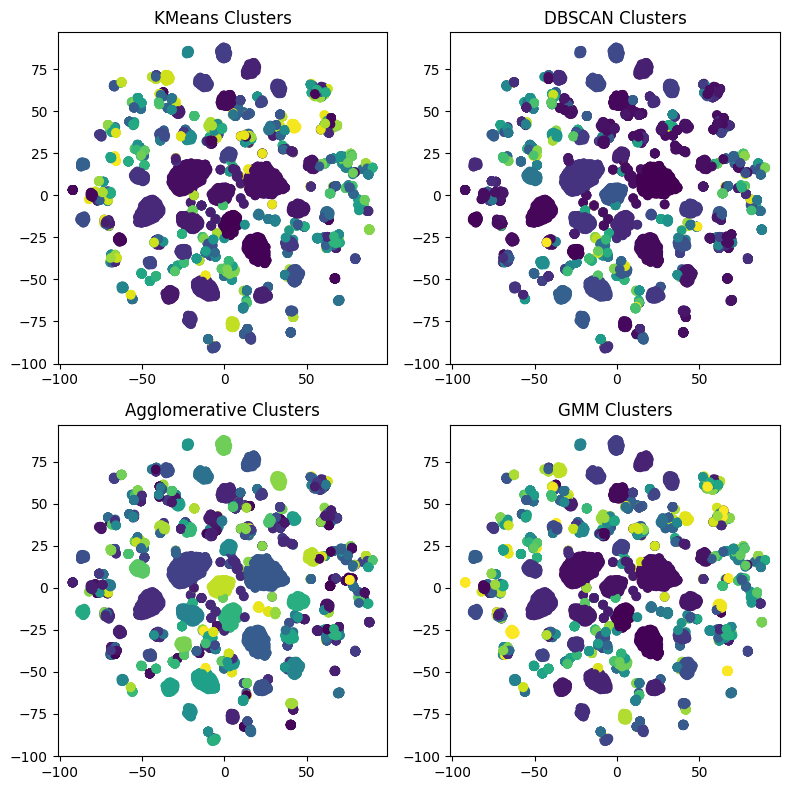

In [21]:
# Visualize all model clusters

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels)
axes[0].set_title('KMeans Clusters')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_labels)
axes[1].set_title('DBSCAN Clusters')

axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=agg_labels)
axes[2].set_title('Agglomerative Clusters')

axes[3].scatter(X_tsne[:, 0], X_tsne[:, 1], c=gmm_labels)
axes[3].set_title('GMM Clusters')

plt.tight_layout()
plt.show()

In [27]:
# assign best model and best model labels

df['cluster'] = kmeans_labels
cluster_model = kmeans_model

### Cosine Similarity

In [30]:
# calculate cosine similarity for all clusters

movie_cos_sims = {}
movie_svd = {}
movie_cast_vec = {}
movie_genre_vec = {}
movie_year_scaler = {}

for i in range(optimal_kmeans_k):
    cluster = df[df['cluster'] == i].copy()

    if cluster.empty:
        continue

    plot_vec = np.vstack(cluster['Plot'].apply(lambda x: plot_vector(x, plot_model)))

    genre_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.0, min_df=1)
    
    try:
        genre_vec = genre_vectorizer.fit_transform([cluster['final_genre']])
    except: 
        genre_vec = genre_model.transform(cluster['final_genre'])
        genre_vectorizer = genre_model

    cast_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.8, min_df=1)
    cast_vec = cast_vectorizer.fit_transform(cluster['final_cast'].fillna('').astype(str))
    
    year_scaler = StandardScaler()
    year_vec = year_scaler.fit_transform(cluster[['Release Year']])

    X = hstack([csr_matrix(year_vec), csr_matrix(cast_vec), csr_matrix(plot_vec), csr_matrix(genre_vec)])

    svd_cos_sim = TruncatedSVD(n_components=10, random_state=42)
    X_reduced = svd_cos_sim.fit_transform(X)

    movie_cos_sims[i] = X_reduced
    movie_svd[i] = svd_cos_sim
    movie_cast_vec[i] = cast_vectorizer
    movie_genre_vec[i] = genre_vectorizer
    movie_year_scaler[i] = year_scaler

In [31]:
# define function to calculate similar movies
def find_similar_movies(movie_details, model, top_n=5):

    genre_vec = genre_model.transform([movie_details['genre']])
    plot_vec = csr_matrix(plot_vector(movie_details['plot'], plot_model).reshape(1, -1))

    X = cluster_svd.transform(hstack([csr_matrix(plot_vec), csr_matrix(genre_vec)]))
    cluster = model.predict(X)[0]

    year_vec = movie_year_scaler[cluster].transform([[movie_details['release_year']]])
    cast_vec = movie_cast_vec[cluster].transform([movie_details['cast']])
    genre_vec = movie_genre_vec[cluster].transform([movie_details['genre']])

    X_cos_sim = hstack([csr_matrix(year_vec), csr_matrix(cast_vec), csr_matrix(plot_vec), csr_matrix(genre_vec)])
    X_cos_sim_reduced = movie_svd[cluster].transform(X_cos_sim)
    sims = cosine_similarity(X_cos_sim_reduced, movie_cos_sims[cluster]).flatten()

    cluster_df = df[df['cluster'] == cluster].copy()
    top_idx = np.argsort(sims)[::-1][:top_n]
    top_movies = cluster_df.iloc[top_idx]
    top_movies['similarity'] = np.round(sims[top_idx], 3)

    return pd.DataFrame(top_movies[['Title', 'final_genre', 'Release Year', 'similarity']])

In [32]:
test_case1 = {'release_year': 2010,
        'genre' : 'sci-fi, action',
        'cast' : 'Leonardo DiCaprio',
        'plot' : 'Dom Cobb dreams within dreams and heist'}

display(Markdown("**Test Case 1 Results**"))
display(find_similar_movies(test_case1, cluster_model))

test_case2 = {'release_year': 2010,
        'genre' : 'sci-fi, action, adventure',
        'cast' : 'Leonardo DiCaprio',
        'plot' : 'Dom Cobb dreams within dreams and heist'}

display(Markdown("**Test Case 2 Results**"))
display(find_similar_movies(test_case2, cluster_model))

display(Markdown("**Test Case 3 Results**"))
test_case3 = {'release_year': 2010,
        'genre' : 'sci-fi, action, adventure',
        'cast' : 'Leonardo DiCaprio, Joseph Gordon-Levitt',
        'plot' : 'Dom Cobb dreams within dreams and heist'}

display(find_similar_movies(test_case3, cluster_model))

**Test Case 1 Results**

,Title,final_genre,Release Year,similarity
7466,X-Men: First Class,"Action,Sci-Fi",2011,0.992
6422,Ultraviolet,"Action,Sci-Fi",2006,0.971
8402,Captain America: Civil War,"Action,Sci-Fi",2016,0.948
7176,Iron Man 2,"Action,Sci-Fi",2010,0.946
7092,X-Men Origins: Wolverine,"Action,Sci-Fi",2009,0.922


**Test Case 2 Results**

,Title,final_genre,Release Year,similarity
7232,Predators,"Action,Adventure,Sci-Fi",2010,0.994
6891,2012,"Action,Adventure,Sci-Fi",2009,0.991
7841,G.I. Joe: Retaliation,"Action,Adventure,Sci-Fi",2013,0.989
7713,Total Recall,"Action,Adventure,Sci-Fi",2012,0.988
7942,Oblivion,"Action,Adventure,Sci-Fi",2013,0.986


**Test Case 3 Results**

,Title,final_genre,Release Year,similarity
7175,Inception,"Action,Adventure,Sci-Fi",2010,0.993
6957,G.I. Joe: The Rise of Cobra,"Action,Adventure,Sci-Fi",2009,0.988
7841,G.I. Joe: Retaliation,"Action,Adventure,Sci-Fi",2013,0.986
7232,Predators,"Action,Adventure,Sci-Fi",2010,0.982
7942,Oblivion,"Action,Adventure,Sci-Fi",2013,0.977


### Sensitivity Analysis on KMeans Model

In [34]:
# Drop genre to test model performance
X_sens = X_plot
sens_svd = TruncatedSVD(n_components= 5, random_state=42)
X_sens_reduced = sens_svd.fit_transform(X_sens)
kmeans_model_sens = clone(cluster_model)
sens_labels = kmeans_model_sens.fit_predict(X_sens)

print(f"Removing Genre: Silhouette Score = {silhouette_score(X_sens_reduced, sens_labels)}, Davies-Bouldin Score = {davies_bouldin_score(X_sens_reduced, sens_labels)}, Calinski-Harabasz Score = {calinski_harabasz_score(X_sens_reduced, sens_labels)}")

Removing Genre: Silhouette Score = -0.03871237114071846, Davies-Bouldin Score = 2.2436772028083407, Calinski-Harabasz Score = 260.70085762601116


In [35]:
# Drop plot to test model performance
X_sens = X_genre
sens_svd = TruncatedSVD(n_components= 5, random_state=42)
X_sens_reduced = sens_svd.fit_transform(X_sens)
kmeans_model_sens = clone(cluster_model)
sens_labels = kmeans_model_sens.fit_predict(X_sens)

print(f"Removing Plot: Silhouette Score = {silhouette_score(X_sens_reduced, sens_labels)}, Davies-Bouldin Score = {davies_bouldin_score(X_sens_reduced, sens_labels)}, Calinski-Harabasz Score = {calinski_harabasz_score(X_sens_reduced, sens_labels)}")

Removing Plot: Silhouette Score = 0.6030645685625127, Davies-Bouldin Score = 2.0189674904524657, Calinski-Harabasz Score = 1688.5358444743053


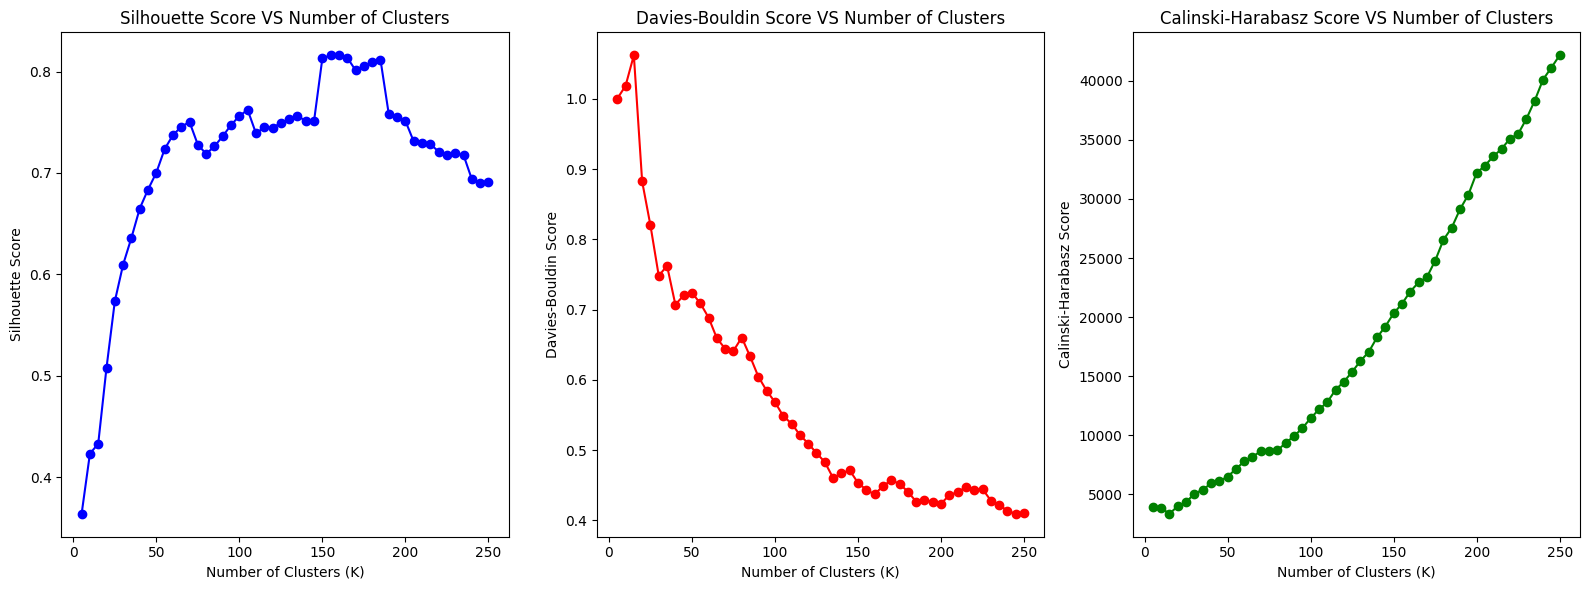

In [36]:
# Test k value sensitivity
k_values = list(range(5, 251, 5))
sil_scores = []
db_scores = []
ch_scores = []

for i in range(5, 251, 5):

    kmeans_model = KMeans(n_clusters= i, random_state=42)
    labels = kmeans_model.fit_predict(X_cluster_reduced)

    sil = silhouette_score(X_cluster_reduced, labels)
    db = davies_bouldin_score(X_cluster_reduced, labels)
    ch = calinski_harabasz_score(X_cluster_reduced, labels)

    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes = axes.flatten()

axes[0].plot(k_values, sil_scores, marker='o', linestyle='-', color='b', label='Silhouette')
axes[0].set_title('Silhouette Score VS Number of Clusters')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Silhouette Score')

axes[1].plot(k_values, db_scores, marker='o', linestyle='-', color='r', label='Davies-Bouldin')
axes[1].set_title('Davies-Bouldin Score VS Number of Clusters')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Davies-Bouldin Score')

axes[2].plot(k_values, ch_scores, marker='o', linestyle='-', color='g', label='Calinski-Harabasz')
axes[2].set_title('Calinski-Harabasz Score VS Number of Clusters')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Calinski-Harabasz Score')

plt.tight_layout()
plt.show()